# SVM Classification Using Predicted Segmentation Mask Features (ACDC)



This notebook trains a SVM classifier on the ACDC dataset using 7 clinical features
extracted from **U-Net predicted segmentation masks**.

Feature extraction is **out-of-fold** to avoid data leakage:
the fold 0 U-Net checkpoint segments only fold 0 validation patients, and so on.

**Evaluation:**
- 4-fold stratified CV on 100 training subjects (same folds as all other experiments)
- Final model trained on all 100, tested on 50 held-out subjects
- Bootstrap confidence intervals (B=1000) on the test set

## 1. Imports

In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import nibabel as nib
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    balanced_accuracy_score,
    roc_auc_score,
    roc_curve,
)

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings("ignore", category=UserWarning)

import sklearn
print(f"numpy: {np.__version__}, pandas: {pd.__version__}, "
      f"sklearn: {sklearn.__version__}, torch: {torch.__version__}")

numpy: 2.4.2, pandas: 3.0.0, sklearn: 1.8.0, torch: 2.10.0+cu128


## 2. U-Net Architecture

Must match the architecture used during segmentation training exactly.

In [2]:
# U-Net architecture — copied exactly from U_NET_Segmentation_Final.ipynb

class DoubleConv(nn.Module):
    """(Conv → BN → ReLU) × 2"""
    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if mid_channels is None:
            mid_channels = out_channels

        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.double_conv(x)


class Down(nn.Module):
    """Downscaling: MaxPool → DoubleConv"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels),
        )

    def forward(self, x):
        return self.maxpool_conv(x)


class Up(nn.Module):
    """Upscaling → concat → DoubleConv"""
    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()

        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels, in_channels // 2)
        else:
            self.up = nn.ConvTranspose2d(
                in_channels, in_channels // 2, kernel_size=2, stride=2
            )
            self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)

        diffY = x2.size(2) - x1.size(2)
        diffX = x2.size(3) - x1.size(3)

        x1 = F.pad(
            x1,
            [diffX // 2, diffX - diffX // 2,
             diffY // 2, diffY - diffY // 2]
        )

        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class OutConv(nn.Module):
    """Final 1×1 convolution"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    """
    Standard U-Net (2D)
    Suitable for ACDC segmentation:
      - in_channels = 1
      - out_channels = 4 (BG, RV, MYO, LV)
    """
    def __init__(self, in_channels=1, out_channels=4, bilinear=False):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.bilinear = bilinear

        self.inc = DoubleConv(in_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)

        factor = 2 if bilinear else 1
        self.down4 = Down(512, 1024 // factor)

        self.up1 = Up(1024, 512 // factor, bilinear)
        self.up2 = Up(512,  256 // factor, bilinear)
        self.up3 = Up(256,  128 // factor, bilinear)
        self.up4 = Up(128,  64, bilinear)

        self.outc = OutConv(64, out_channels)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        x = self.up1(x5, x4)
        x = self.up2(x,  x3)
        x = self.up3(x,  x2)
        x = self.up4(x,  x1)

        return self.outc(x)


print("UNet architecture defined.")

UNet architecture defined.


## 3. Configuration

Paths, class mapping, model hyperparameters, and the 4-fold CV splits.

The fold splits are the same ones used across all experiments in this thesis
so results are directly comparable.

In [3]:
# --- Paths ---
ACDC_ROOT    = Path(r"C:\Users\manoj\Desktop\Thesis\ACDC\ACDC\database")
TRAINING_DIR = ACDC_ROOT / "training"
TESTING_DIR  = ACDC_ROOT / "testing"

# U-Net segmentation CV outputs (fold_00, fold_01, ...)
SEG_CV_ROOT = Path(r"C:\Users\manoj\Desktop\Thesis\16873796\runs_acdc_segmentation_cv")

LABELS_TRAIN_CSV = Path(r"C:\Users\manoj\Desktop\Thesis\labels_acdc_5class.csv")
LABELS_TEST_CSV  = Path(r"C:\Users\manoj\Desktop\Thesis\labels_acdc_5class_test.csv")

OUT_DIR = Path(r"C:\Users\manoj\Desktop\Thesis\svm_seg_results")
FIG_DIR = OUT_DIR / "thesis_figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# --- Device ---
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE    = 256   # must match U-Net training
SLICE_BATCH = 16

# --- Classes ---
CLASS_MAP    = {"NOR": 0, "MINF": 1, "DCM": 2, "HCM": 3, "RV": 4}
CLASS_NAMES  = {0: "NOR", 1: "MINF", 2: "DCM", 3: "HCM", 4: "RV"}
CLASS_LABELS = ["NOR", "MINF", "DCM", "HCM", "RV"]
CLASSES      = [0, 1, 2, 3, 4]
NUM_CLASSES  = 5

# --- Segmentation labels (ACDC standard) ---
RV_LABEL  = 1   # right ventricle
MYO_LABEL = 2   # myocardium
LV_LABEL  = 3   # left ventricle
MYO_DENSITY_G_PER_ML = 1.05  # standard myocardial density

# --- Features ---
FEATURE_COLS = [
    "LVEDV_ml", "LVESV_ml", "LVEF_pct",
    "RVEDV_ml", "RVESV_ml", "RVEF_pct",
    "MYO_mass_g",
]

# --- Reproducibility ---
SEED = 0
np.random.seed(SEED)

# --- SVM hyperparameters ---
# RBF kernel, C=10 and gamma='scale' are strong defaults for small tabular datasets.
# probability=True is required to compute predict_proba for AUC.
# class_weight='balanced' matches the RF setup.
MODEL_PARAMS = dict(
    C=10,
    kernel="rbf",
    gamma="scale",
    class_weight="balanced",
    probability=True,
    random_state=SEED,
)

train_ids_fold0 = [1,2,3,4,5,7,8,9,10,11,12,13,15,18,19,21,22,25,26,27,28,29,30,31,32,33,35,37,38,39,40,41,42,43,44,45,46,47,48,49,52,53,54,55,58,60,61,65,66,67,68,69,71,72,73,74,75,76,77,78,80,81,82,83,84,85,86,87,88,89,90,92,94,96,97]
val_ids_fold0   = [0,6,14,16,17,20,23,24,34,36,50,51,56,57,59,62,63,64,70,79,91,93,95,98,99]

train_ids_fold1 = [0,1,2,4,6,7,8,9,10,11,12,14,16,17,18,20,21,22,23,24,25,26,27,28,31,33,34,35,36,37,40,41,42,43,44,45,48,49,50,51,55,56,57,58,59,62,63,64,65,66,67,68,70,71,72,73,74,76,77,79,83,84,85,87,88,90,91,92,93,94,95,96,97,98,99]
val_ids_fold1   = [3,5,13,15,19,29,30,32,38,39,46,47,52,53,54,60,61,69,75,78,80,81,82,86,89]

train_ids_fold2 = [0,1,3,5,6,7,8,10,13,14,15,16,17,18,19,20,23,24,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,46,47,48,49,50,51,52,53,54,56,57,59,60,61,62,63,64,65,66,68,69,70,72,74,75,78,79,80,81,82,85,86,89,90,91,92,93,94,95,96,98,99]
val_ids_fold2   = [2,4,9,11,12,21,22,25,26,27,43,44,45,55,58,67,71,73,76,77,83,84,87,88,97]

train_ids_fold3 = [0,2,3,4,5,6,9,11,12,13,14,15,16,17,19,20,21,22,23,24,25,26,27,29,30,32,34,36,38,39,43,44,45,46,47,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,67,69,70,71,73,75,76,77,78,79,80,81,82,83,84,86,87,88,89,91,93,95,97,98,99]
val_ids_fold3   = [1,7,8,10,18,28,31,33,35,37,40,41,42,48,49,65,66,68,72,74,85,90,92,94,96]

FOLDS = [
    (train_ids_fold0, val_ids_fold0),
    (train_ids_fold1, val_ids_fold1),
    (train_ids_fold2, val_ids_fold2),
    (train_ids_fold3, val_ids_fold3),
]

# Quick sanity check
for f, (tr, va) in enumerate(FOLDS):
    assert len(tr) == 75 and len(va) == 25, f"Fold {f} size mismatch"
    assert set(tr) & set(va) == set(), f"Fold {f} overlap"
    assert set(tr) | set(va) == set(range(100)), f"Fold {f} missing subjects"

print(f"Device: {DEVICE}")
print(f"Output dir: {OUT_DIR}")
print(f"Figures dir: {FIG_DIR}")

Device: cuda
Output dir: C:\Users\manoj\Desktop\Thesis\svm_seg_results
Figures dir: C:\Users\manoj\Desktop\Thesis\svm_seg_results\thesis_figures


## 4. Helper Functions

Functions for reading ACDC metadata, loading NIfTI files, U-Net inference,
computing volumes/features, and evaluating classification performance.

In [4]:
def read_info_cfg(info_path):
    """Parse ED/ES frame numbers and pathology Group from an ACDC Info.cfg file."""
    ed = es = group = None
    for line in Path(info_path).read_text().splitlines():
        line = line.strip()
        if line.startswith("ED:"):
            ed = int(line.split(":")[1].strip())
        elif line.startswith("ES:"):
            es = int(line.split(":")[1].strip())
        elif line.startswith("Group:"):
            group = line.split(":")[1].strip()
    if ed is None or es is None:
        raise ValueError(f"Missing ED/ES in {info_path}")
    return ed, es, group


def load_nifti(path):
    """Load a NIfTI file. Returns (data_array, voxel_spacing_mm)."""
    nii = nib.load(str(path))
    data = nii.get_fdata()
    voxel_mm = tuple(float(x) for x in nii.header.get_zooms()[:3])
    return data, voxel_mm


def volume_ml(mask_3d, label, voxel_mm):
    """Volume in mL for voxels matching `label`. Converts mm³ -> mL (÷1000)."""
    dx, dy, dz = voxel_mm
    voxel_vol_mm3 = dx * dy * dz
    voxel_count = np.sum(mask_3d == label)
    return float((voxel_count * voxel_vol_mm3) / 1000.0)


def compute_patient_features(mask_ed, mask_es, voxel_mm):
    """
    Compute 7 clinical features from ED and ES segmentation masks.
    Feature definitions follow Srikijkasemwat et al. (2025), Table 1.
    """
    # LV
    lvedv = volume_ml(mask_ed, LV_LABEL, voxel_mm)
    lvesv = volume_ml(mask_es, LV_LABEL, voxel_mm)
    lvef  = ((lvedv - lvesv) / (lvedv + 1e-8)) * 100.0

    # RV
    rvedv = volume_ml(mask_ed, RV_LABEL, voxel_mm)
    rvesv = volume_ml(mask_es, RV_LABEL, voxel_mm)
    rvef  = ((rvedv - rvesv) / (rvedv + 1e-8)) * 100.0

    # Myocardial mass (ED frame, density = 1.05 g/mL)
    myo_vol_ml = volume_ml(mask_ed, MYO_LABEL, voxel_mm)
    myo_mass_g = myo_vol_ml * MYO_DENSITY_G_PER_ML

    return dict(
        LVEDV_ml=float(lvedv),
        LVESV_ml=float(lvesv),
        LVEF_pct=float(lvef),
        RVEDV_ml=float(rvedv),
        RVESV_ml=float(rvesv),
        RVEF_pct=float(rvef),
        MYO_mass_g=float(myo_mass_g),
    )


def patient_dir_from_id(root, pid0):
    """0-based index -> patient directory. pid0=0 -> patient001."""
    return root / f"patient{pid0 + 1:03d}"


def compute_macro_specificity(cm):
    """Per-class specificity (one-vs-rest TN/(TN+FP)), then macro-average."""
    n_classes = cm.shape[0]
    total = cm.sum()
    specs = []
    for i in range(n_classes):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = total - tp - fn - fp
        spec = (tn / (tn + fp)) if (tn + fp) > 0 else np.nan
        specs.append(spec)
    specs = np.asarray(specs, dtype=np.float64)
    return specs, float(np.nanmean(specs))


def safe_proba_matrix(proba, model_classes, all_classes):
    """
    Align predict_proba output to the full class list.
    Needed because sklearn only returns columns for classes seen during fit.
    """
    out = np.zeros((proba.shape[0], len(all_classes)), dtype=np.float64)
    class_to_idx = {c: i for i, c in enumerate(model_classes)}
    for j, c in enumerate(all_classes):
        if c in class_to_idx:
            out[:, j] = proba[:, class_to_idx[c]]
    return out


def compute_metrics_multiclass(y_true, y_prob, classes):
    """Compute accuracy, macro F1/precision/recall, balanced acc, specificity, AUC."""
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = y_prob.argmax(axis=1)

    cm = confusion_matrix(y_true, y_pred, labels=classes)

    y_true_bin = label_binarize(y_true, classes=classes)
    try:
        auc_macro_ovr = roc_auc_score(
            y_true_bin, y_prob, average="macro", multi_class="ovr")
    except ValueError:
        auc_macro_ovr = np.nan

    acc             = accuracy_score(y_true, y_pred)
    f1_macro        = f1_score(y_true, y_pred, labels=classes, average="macro", zero_division=0)
    precision_macro = precision_score(y_true, y_pred, labels=classes, average="macro", zero_division=0)
    recall_macro    = recall_score(y_true, y_pred, labels=classes, average="macro", zero_division=0)
    bal_acc         = balanced_accuracy_score(y_true, y_pred)
    _, spec_macro   = compute_macro_specificity(cm)

    return dict(
        auc_macro_ovr=float(auc_macro_ovr),
        acc=float(acc),
        f1_macro=float(f1_macro),
        precision_macro=float(precision_macro),
        recall_macro=float(recall_macro),
        balanced_acc=float(bal_acc),
        specificity_macro=float(spec_macro),
        y_pred=y_pred,
        cm=cm,
    )


def bootstrap_summary(series):
    """Mean, std, 95% percentile CI."""
    x = pd.Series(series).dropna().astype(float).values
    if len(x) == 0:
        return {"mean": np.nan, "std": np.nan,
                "ci95_low": np.nan, "ci95_high": np.nan, "n_valid": 0}
    return {
        "mean":      float(np.mean(x)),
        "std":       float(np.std(x, ddof=1)) if len(x) > 1 else 0.0,
        "ci95_low":  float(np.percentile(x, 2.5)),
        "ci95_high": float(np.percentile(x, 97.5)),
        "n_valid":   int(len(x)),
    }


print("Helper functions defined.")

Helper functions defined.


### U-Net Inference Helpers

In [5]:
def zscore(x):
    """Z-score normalise a 2D slice before U-Net inference."""
    x = x.astype(np.float32)
    return (x - x.mean()) / (x.std() + 1e-8)


def infer_mask_3d(model, vol_hws, img_size, slice_batch):
    """
    Run U-Net slice-by-slice on a 3D volume.
    vol_hws: [H, W, S] numpy float array.
    Returns: [H, W, S] int16 predicted mask.
    """
    H, W, S = vol_hws.shape
    pred = np.zeros((H, W, S), dtype=np.int16)

    model.eval()
    with torch.no_grad():
        for start in range(0, S, slice_batch):
            end = min(S, start + slice_batch)
            batch_slices = []
            for s in range(start, end):
                sl = zscore(vol_hws[:, :, s])
                t  = torch.from_numpy(sl).unsqueeze(0).unsqueeze(0)  # [1,1,H,W]
                t  = F.interpolate(t, size=(img_size, img_size),
                                   mode="bilinear", align_corners=False)
                batch_slices.append(t)
            x = torch.cat(batch_slices, dim=0).to(DEVICE, dtype=torch.float32)
            logits = model(x)
            p = torch.argmax(logits, dim=1).unsqueeze(1).float()
            p = F.interpolate(p, size=(H, W), mode="nearest") \
                 .squeeze(1).cpu().numpy().astype(np.int16)
            for i, s in enumerate(range(start, end)):
                pred[:, :, s] = p[i]
    return pred

## 5. Feature Extraction — Training Set (n=100)

For each fold: load the fold-specific U-Net checkpoint → segment validation patients only → compute 7 features from predicted masks.

In [6]:
df_labels_train = pd.read_csv(LABELS_TRAIN_CSV)
label_map_train = dict(zip(df_labels_train["patient_id"],
                           df_labels_train["label"]))
print(f"Training labels: {len(label_map_train)} patients")

all_rows = []

for fold_idx, (train_ids, val_ids) in enumerate(FOLDS):
    fold_dir = SEG_CV_ROOT / f"fold_{fold_idx:02d}"
    ckpt_path = fold_dir / f"best_unet_acdc_fold{fold_idx}.pth"
    assert ckpt_path.exists(), f"Missing checkpoint: {ckpt_path}"

    # Load U-Net checkpoint for this fold
    model = UNet(in_channels=1, out_channels=4).to(DEVICE)
    ckpt  = torch.load(ckpt_path, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state"])
    model.eval()
    print(f"\nFold {fold_idx} — segmenting {len(val_ids)} validation patients")
    print(f"Checkpoint: {ckpt_path}")

    for pid0 in val_ids:
        pid_str = f"patient{pid0 + 1:03d}"
        pdir    = patient_dir_from_id(TRAINING_DIR, pid0)
        assert pdir.exists(), f"Missing: {pdir}"

        ed_frame, es_frame, group = read_info_cfg(pdir / "Info.cfg")

        ed_path = pdir / f"{pid_str}_frame{ed_frame:02d}.nii.gz"
        es_path = pdir / f"{pid_str}_frame{es_frame:02d}.nii.gz"
        assert ed_path.exists(), f"Missing ED: {ed_path}"
        assert es_path.exists(), f"Missing ES: {es_path}"

        vol_ed, voxel_mm = load_nifti(ed_path)
        vol_es, _        = load_nifti(es_path)

        pred_ed = infer_mask_3d(model, vol_ed, IMG_SIZE, SLICE_BATCH)
        pred_es = infer_mask_3d(model, vol_es, IMG_SIZE, SLICE_BATCH)

        feats = compute_patient_features(pred_ed, pred_es, voxel_mm)

        label = label_map_train.get(pid_str)
        if label is None:
            label = CLASS_MAP.get(group)
        assert label is not None, f"No label for {pid_str}"

        row = {"patient_id": pid_str, "label": int(label), "group": group,
               "fold_source": fold_idx,
               "dx_mm": voxel_mm[0], "dy_mm": voxel_mm[1], "dz_mm": voxel_mm[2]}
        row.update(feats)
        all_rows.append(row)

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

df_train = pd.DataFrame(all_rows)
df_train = df_train.sort_values("patient_id").reset_index(drop=True)  # ensure rows match patient order 0-99 for correct fold indexing
assert df_train["patient_id"].nunique() == 100, "Not all 100 patients extracted!"
df_train.to_csv(OUT_DIR / "train_features_pred.csv", index=False)

print(f"\nShape: {df_train.shape}")
print(f"\nClass distribution:")
for c in CLASSES:
    print(f"  {CLASS_NAMES[c]:5s}: {(df_train['label'] == c).sum()}")

print(f"\nFeature stats:")
print(df_train[FEATURE_COLS].describe().round(2).to_string())

Training labels: 100 patients

Fold 0 — segmenting 25 validation patients
Checkpoint: C:\Users\manoj\Desktop\Thesis\16873796\runs_acdc_segmentation_cv\fold_00\best_unet_acdc_fold0.pth

Fold 1 — segmenting 25 validation patients
Checkpoint: C:\Users\manoj\Desktop\Thesis\16873796\runs_acdc_segmentation_cv\fold_01\best_unet_acdc_fold1.pth

Fold 2 — segmenting 25 validation patients
Checkpoint: C:\Users\manoj\Desktop\Thesis\16873796\runs_acdc_segmentation_cv\fold_02\best_unet_acdc_fold2.pth

Fold 3 — segmenting 25 validation patients
Checkpoint: C:\Users\manoj\Desktop\Thesis\16873796\runs_acdc_segmentation_cv\fold_03\best_unet_acdc_fold3.pth

Shape: (100, 14)

Class distribution:
  NOR  : 20
  MINF : 20
  DCM  : 20
  HCM  : 20
  RV   : 20

Feature stats:
       LVEDV_ml  LVESV_ml  LVEF_pct  RVEDV_ml  RVESV_ml  RVEF_pct  MYO_mass_g
count    100.00    100.00    100.00    100.00    100.00    100.00      100.00
mean     160.60     99.27     43.66    146.97     94.24     38.47      141.11
std  

## 6. Feature Extraction — Test Set (n=50)

Uses fold 0 checkpoint for inference. Same procedure as M7.

In [7]:
df_labels_test = pd.read_csv(LABELS_TEST_CSV)
label_map_test = dict(zip(df_labels_test["patient_id"],
                          df_labels_test["label"]))
print(f"Test labels: {len(label_map_test)} patients")

# Use fold 0 checkpoint for test inference
ckpt_path = SEG_CV_ROOT / "fold_00" / "best_unet_acdc_fold0.pth"
assert ckpt_path.exists(), f"Missing checkpoint: {ckpt_path}"

model_test = UNet(in_channels=1, out_channels=4).to(DEVICE)
ckpt = torch.load(ckpt_path, map_location=DEVICE)
model_test.load_state_dict(ckpt["model_state"])
model_test.eval()
print(f"Loaded checkpoint: {ckpt_path}")

test_rows = []
for pid_abs in range(101, 151):
    pid_str = f"patient{pid_abs:03d}"
    pdir    = TESTING_DIR / pid_str
    assert pdir.exists(), f"Missing: {pdir}"

    ed_frame, es_frame, group = read_info_cfg(pdir / "Info.cfg")

    ed_path = pdir / f"{pid_str}_frame{ed_frame:02d}.nii.gz"
    es_path = pdir / f"{pid_str}_frame{es_frame:02d}.nii.gz"

    vol_ed, voxel_mm = load_nifti(ed_path)
    vol_es, _        = load_nifti(es_path)

    pred_ed = infer_mask_3d(model_test, vol_ed, IMG_SIZE, SLICE_BATCH)
    pred_es = infer_mask_3d(model_test, vol_es, IMG_SIZE, SLICE_BATCH)

    feats = compute_patient_features(pred_ed, pred_es, voxel_mm)

    label = label_map_test.get(pid_str)
    if label is None and group is not None:
        label = CLASS_MAP.get(group)
    assert label is not None, f"No label for {pid_str}"

    row = {"patient_id": pid_str, "label": int(label), "group": group,
           "dx_mm": voxel_mm[0], "dy_mm": voxel_mm[1], "dz_mm": voxel_mm[2]}
    row.update(feats)
    test_rows.append(row)

del model_test
if torch.cuda.is_available():
    torch.cuda.empty_cache()

df_test = pd.DataFrame(test_rows)
df_test.to_csv(OUT_DIR / "test_features_pred.csv", index=False)

print(f"Shape: {df_test.shape}")
print(f"\nClass distribution:")
for c in CLASSES:
    print(f"  {CLASS_NAMES[c]:5s}: {(df_test['label'] == c).sum()}")

print(f"\nFeature stats:")
print(df_test[FEATURE_COLS].describe().round(2).to_string())

Test labels: 50 patients
Loaded checkpoint: C:\Users\manoj\Desktop\Thesis\16873796\runs_acdc_segmentation_cv\fold_00\best_unet_acdc_fold0.pth
Shape: (50, 13)

Class distribution:
  NOR  : 10
  MINF : 10
  DCM  : 10
  HCM  : 10
  RV   : 10

Feature stats:
       LVEDV_ml  LVESV_ml  LVEF_pct  RVEDV_ml  RVESV_ml  RVEF_pct  MYO_mass_g
count     50.00     50.00     50.00     50.00     50.00     50.00       50.00
mean     172.16    101.17     47.32    164.34     99.33     41.94      147.90
std       70.85     75.46     19.47     68.48     56.37     16.22       45.92
min       64.27     25.55      8.15     43.26      8.66      7.49       54.47
25%      125.08     45.62     28.85    114.89     56.84     34.89      115.36
50%      146.42     62.88     54.44    157.30     91.97     41.91      142.82
75%      209.00    148.88     63.49    201.76    139.17     49.35      168.35
max      369.41    308.37     78.69    380.65    294.56     83.77      280.72


## 7. 4-Fold Cross-Validation

Pipeline per fold: `SimpleImputer(median) → StandardScaler → SVM`.

Train: (100, 7), Test: (50, 7)


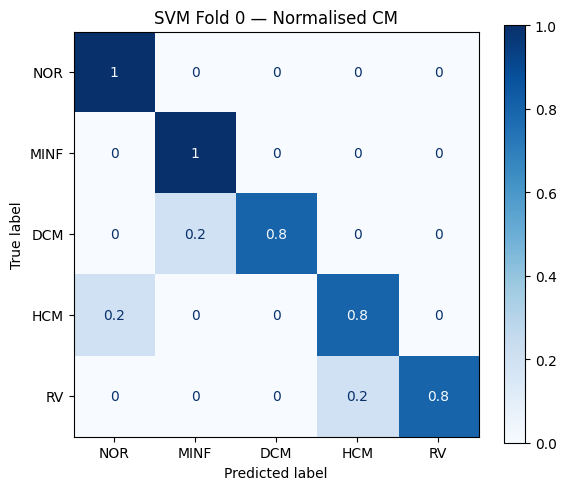

Fold 0: acc=0.880  F1=0.879  AUC=0.950


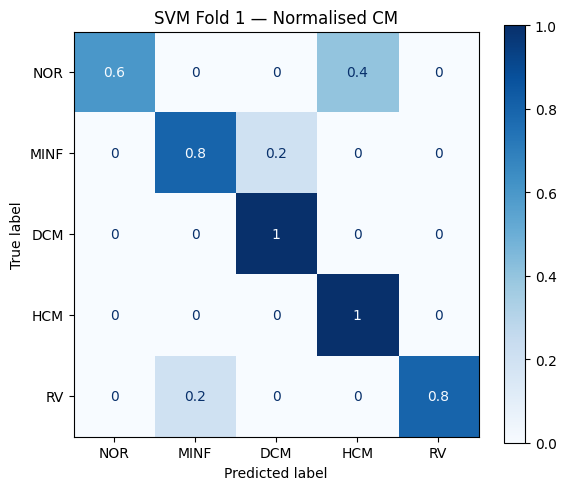

Fold 1: acc=0.840  F1=0.836  AUC=0.988


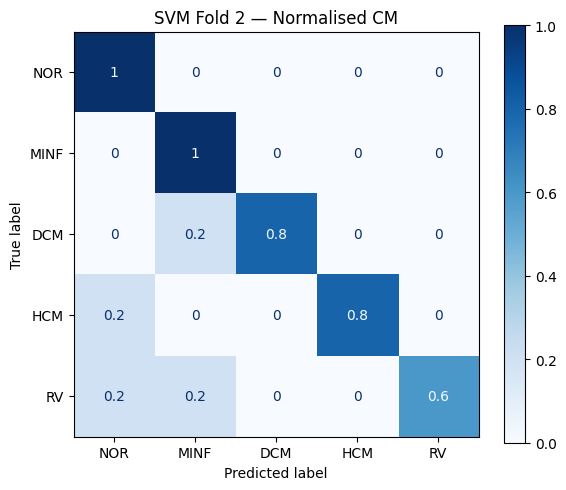

Fold 2: acc=0.840  F1=0.839  AUC=0.950


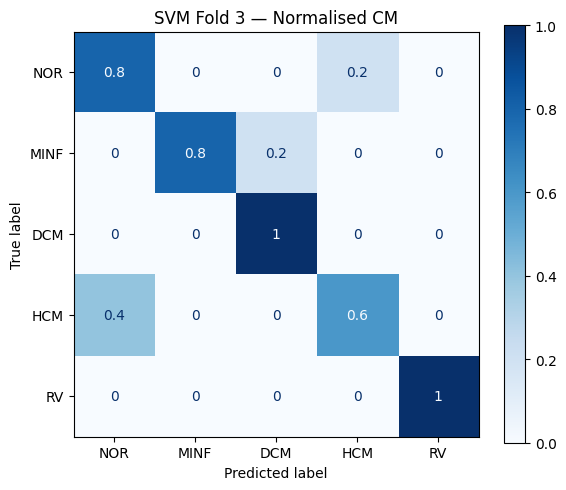

Fold 3: acc=0.840  F1=0.838  AUC=0.984

SVM — 4-FOLD CV RESULTS
  acc                    0.850 ± 0.020
  f1_macro               0.848 ± 0.021
  precision_macro        0.875 ± 0.019
  recall_macro           0.850 ± 0.020
  balanced_acc           0.850 ± 0.020
  specificity_macro      0.962 ± 0.005
  auc_macro_ovr          0.968 ± 0.021


In [8]:
X_tr_all = df_train[FEATURE_COLS].values
y_tr_all = df_train["label"].values.astype(int)
X_te = df_test[FEATURE_COLS].values
y_te = df_test["label"].values.astype(int)

print(f"Train: {X_tr_all.shape}, Test: {X_te.shape}")

cv_rows = []

for fold_idx, (train_ids, val_ids) in enumerate(FOLDS):
    fold_dir = OUT_DIR / f"fold_{fold_idx:02d}"
    fold_dir.mkdir(parents=True, exist_ok=True)

    X_tr, y_tr = X_tr_all[train_ids], y_tr_all[train_ids]
    X_va, y_va = X_tr_all[val_ids],   y_tr_all[val_ids]

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("svm", SVC(**MODEL_PARAMS)),
    ])
    model.fit(X_tr, y_tr)

    y_prob_va = safe_proba_matrix(
        model.predict_proba(X_va), model.classes_, CLASSES)
    met = compute_metrics_multiclass(y_va, y_prob_va, CLASSES)
    y_pred_va = met["y_pred"]

    # Confusion matrix
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(
        y_va, y_pred_va,
        display_labels=[CLASS_NAMES[c] for c in CLASSES],
        normalize="true", cmap="Blues", ax=ax)
    ax.set_title(f"SVM Fold {fold_idx} — Normalised CM")
    plt.tight_layout()
    plt.savefig(fold_dir / "confusion_matrix.png", dpi=150)
    plt.show()

    cv_rows.append({
        "fold":               fold_idx,
        "auc_macro_ovr":      met["auc_macro_ovr"],
        "acc":                met["acc"],
        "f1_macro":           met["f1_macro"],
        "precision_macro":    met["precision_macro"],
        "recall_macro":       met["recall_macro"],
        "balanced_acc":       met["balanced_acc"],
        "specificity_macro":  met["specificity_macro"],
    })

    print(f"Fold {fold_idx}: acc={met['acc']:.3f}  F1={met['f1_macro']:.3f}  "
          f"AUC={met['auc_macro_ovr']:.3f}")

# --- CV summary ---
cv_df = pd.DataFrame(cv_rows)
cv_df.to_csv(OUT_DIR / "cv_results.csv", index=False)

print(f"\n{'='*50}")
print("SVM — 4-FOLD CV RESULTS")
print(f"{'='*50}")
for col in ["acc", "f1_macro", "precision_macro", "recall_macro",
            "balanced_acc", "specificity_macro", "auc_macro_ovr"]:
    vals = cv_df[col].values
    print(f"  {col:<22} {np.mean(vals):.3f} ± {np.std(vals, ddof=1):.3f}")

## 8. Test Evaluation

Train on all 100 subjects, test on the 50 held-out subjects.

Test Accuracy     : 80.0%
Test Macro F1     : 79.9%
Test Macro Prec   : 80.1%
Test Macro Recall : 80.0%
Test Balanced Acc : 80.0%
Test Macro Spec   : 95.0%
Test Macro AUC    : 0.9575

              precision    recall  f1-score   support

         NOR       0.82      0.90      0.86        10
        MINF       0.70      0.70      0.70        10
         DCM       0.78      0.70      0.74        10
         HCM       0.82      0.90      0.86        10
          RV       0.89      0.80      0.84        10

    accuracy                           0.80        50
   macro avg       0.80      0.80      0.80        50
weighted avg       0.80      0.80      0.80        50



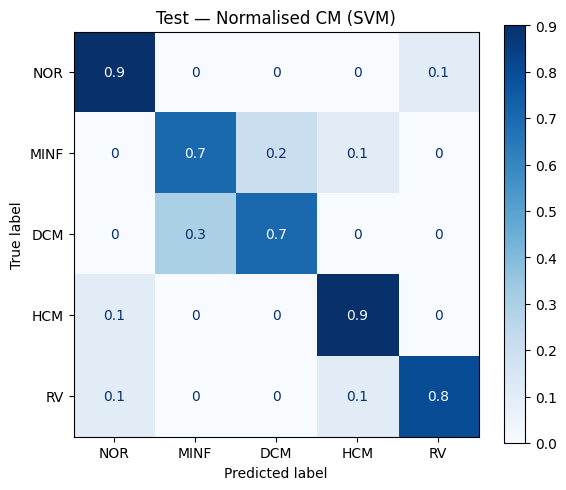

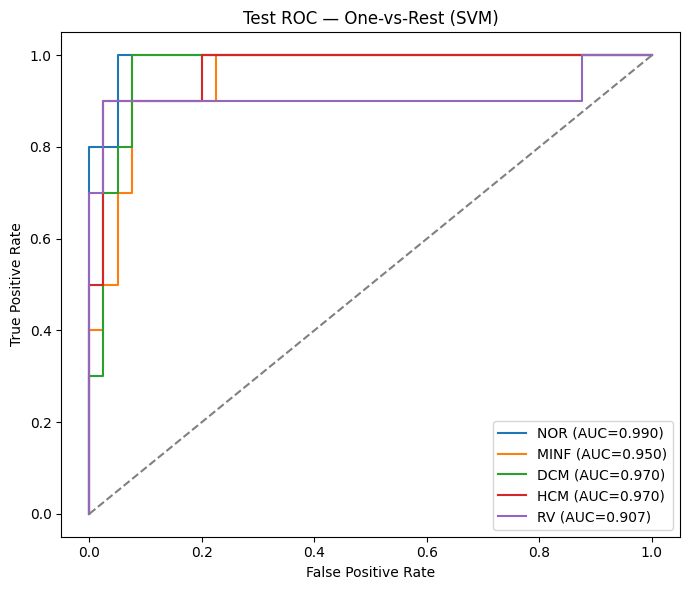

In [9]:
model_final = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("svm", SVC(**MODEL_PARAMS)),
])
model_final.fit(X_tr_all, y_tr_all)

y_prob_te = safe_proba_matrix(
    model_final.predict_proba(X_te), model_final.classes_, CLASSES)
met_te = compute_metrics_multiclass(y_te, y_prob_te, CLASSES)
y_pred_te = met_te["y_pred"]

print(f"Test Accuracy     : {met_te['acc']*100:.1f}%")
print(f"Test Macro F1     : {met_te['f1_macro']*100:.1f}%")
print(f"Test Macro Prec   : {met_te['precision_macro']*100:.1f}%")
print(f"Test Macro Recall : {met_te['recall_macro']*100:.1f}%")
print(f"Test Balanced Acc : {met_te['balanced_acc']*100:.1f}%")
print(f"Test Macro Spec   : {met_te['specificity_macro']*100:.1f}%")
print(f"Test Macro AUC    : {met_te['auc_macro_ovr']:.4f}")

print(f"\n{classification_report(y_te, y_pred_te, target_names=CLASS_LABELS)}")

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_te, y_pred_te,
    display_labels=[CLASS_NAMES[c] for c in CLASSES],
    normalize="true", cmap="Blues", ax=ax)
ax.set_title("Test — Normalised CM (SVM)")
plt.tight_layout()
plt.savefig(OUT_DIR / "test_confusion_matrix.png", dpi=150)
plt.show()

# ROC curves
y_te_bin = label_binarize(y_te, classes=CLASSES)
fig, ax = plt.subplots(figsize=(7, 6))
for i, c in enumerate(CLASSES):
    if len(np.unique(y_te_bin[:, i])) < 2:
        continue
    fpr, tpr, _ = roc_curve(y_te_bin[:, i], y_prob_te[:, i])
    auc_i = roc_auc_score(y_te_bin[:, i], y_prob_te[:, i])
    ax.plot(fpr, tpr, label=f"{CLASS_NAMES[c]} (AUC={auc_i:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Test ROC — One-vs-Rest (SVM)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(OUT_DIR / "test_roc_ovr.png", dpi=150)
plt.show()

## 9. Bootstrap Confidence Intervals (B=1000)

Resample the 50 test subjects with replacement 1000 times to get
mean ± std and 95% CIs for all metrics.

In [10]:
N_BOOT = 1000
rng = np.random.default_rng(seed=SEED)

boot_rows = []
n_test = len(y_te)

for b in range(N_BOOT):
    idx = rng.integers(0, n_test, size=n_test)
    y_true_b = y_te[idx]
    y_prob_b = y_prob_te[idx]
    met_b = compute_metrics_multiclass(y_true_b, y_prob_b, CLASSES)
    boot_rows.append({
        "bootstrap_id":      b,
        "auc_macro_ovr":     met_b["auc_macro_ovr"],
        "acc":               met_b["acc"],
        "f1_macro":          met_b["f1_macro"],
        "precision_macro":   met_b["precision_macro"],
        "recall_macro":      met_b["recall_macro"],
        "balanced_acc":      met_b["balanced_acc"],
        "specificity_macro": met_b["specificity_macro"],
    })

boot_df = pd.DataFrame(boot_rows)
boot_df.to_csv(OUT_DIR / "test_bootstrap_1000_metrics.csv", index=False)

metric_order = [
    ("acc",               "Accuracy"),
    ("precision_macro",   "Macro Precision"),
    ("recall_macro",      "Macro Recall"),
    ("f1_macro",          "Macro F1-score"),
    ("balanced_acc",      "Balanced Accuracy"),
    ("specificity_macro", "Macro Specificity"),
    ("auc_macro_ovr",     "Macro OvR AUC"),
]

boot_summary_rows = []
print(f"{'Metric':<22} {'Mean':>8} {'Std':>8} {'95% CI':>18}")
print("-" * 58)
for key, name in metric_order:
    s = bootstrap_summary(boot_df[key])
    boot_summary_rows.append({
        "metric": key, "display_name": name,
        "mean": s["mean"], "std": s["std"],
        "ci95_low": s["ci95_low"], "ci95_high": s["ci95_high"],
        "n_valid": s["n_valid"],
    })
    print(f"{name:<22} {s['mean']:8.3f} {s['std']:8.3f} "
          f"[{s['ci95_low']:.3f}, {s['ci95_high']:.3f}]")

boot_summary_df = pd.DataFrame(boot_summary_rows)
boot_summary_df.to_csv(OUT_DIR / "test_bootstrap_1000_summary.csv", index=False)

Metric                     Mean      Std             95% CI
----------------------------------------------------------
Accuracy                  0.800    0.058 [0.680, 0.900]
Macro Precision           0.801    0.060 [0.679, 0.909]
Macro Recall              0.800    0.060 [0.677, 0.903]
Macro F1-score            0.790    0.061 [0.665, 0.896]
Balanced Accuracy         0.800    0.060 [0.677, 0.903]
Macro Specificity         0.950    0.014 [0.919, 0.975]
Macro OvR AUC             0.958    0.023 [0.909, 0.991]


## 10. Visualization figure

All figures saved as PNG (300 dpi) and PDF for the thesis report.

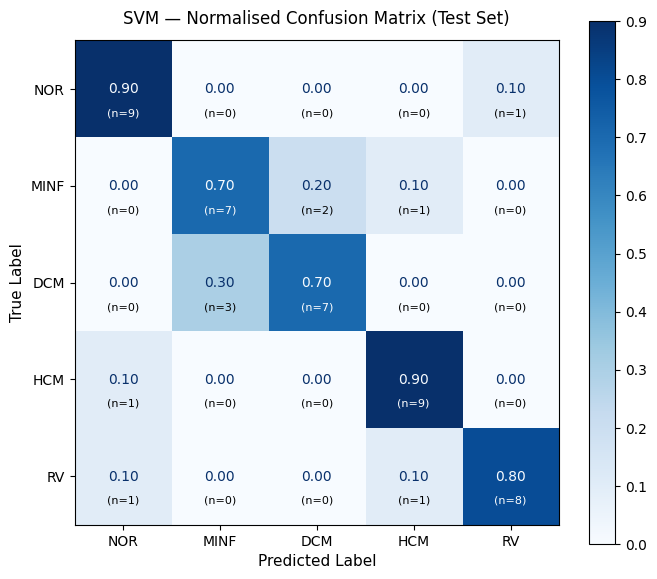

Saved: confusion_matrix_thesis.png / .pdf


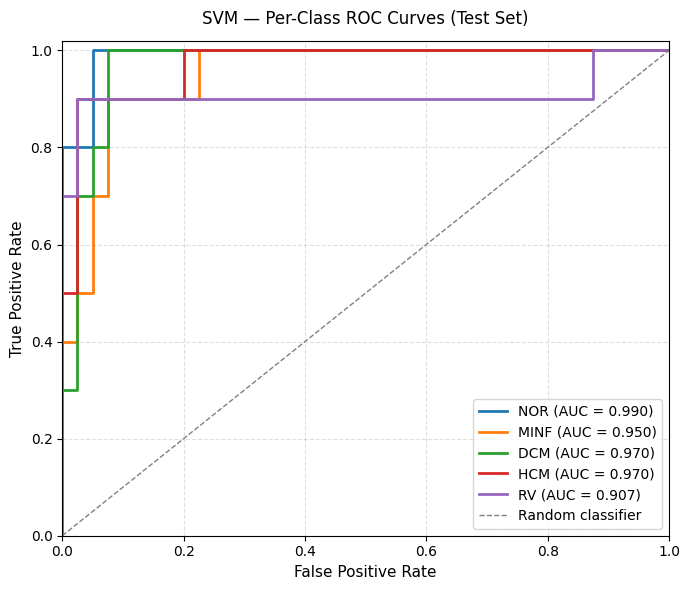

Saved: roc_curves_thesis.png / .pdf


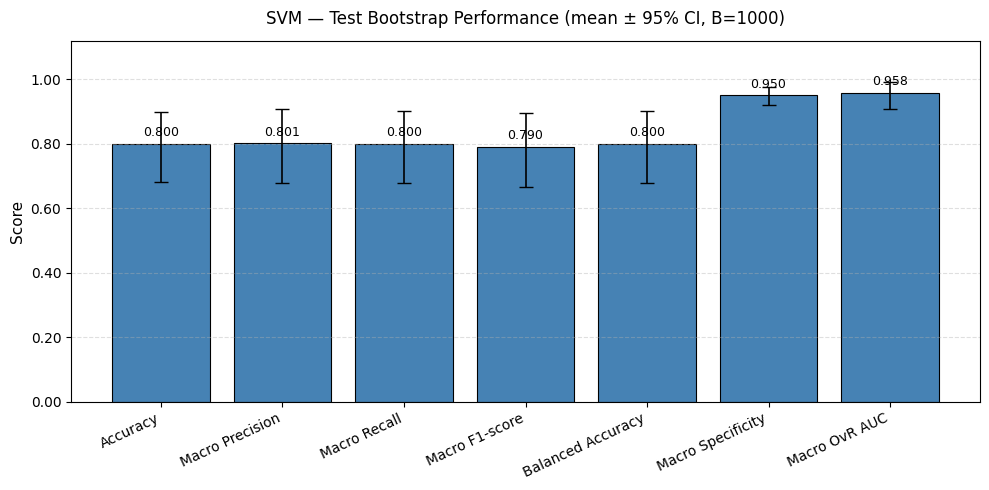

Saved: bootstrap_bar_thesis.png / .pdf


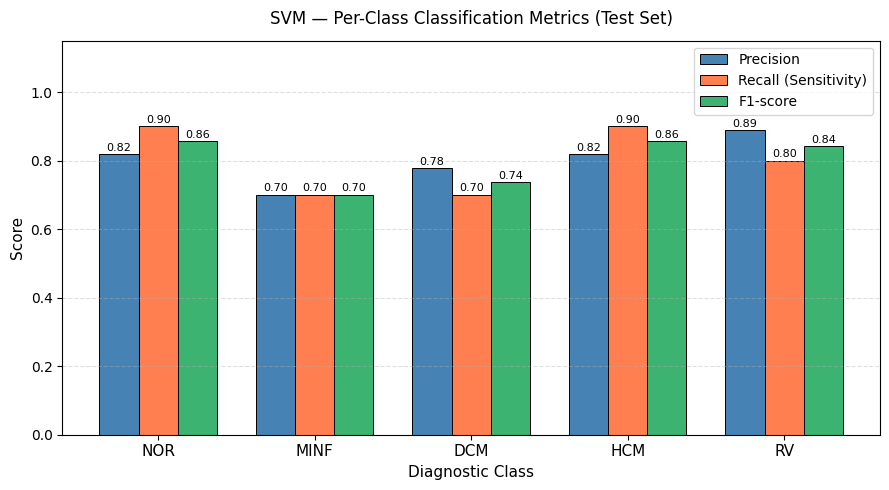

Saved: per_class_metrics_thesis.png / .pdf


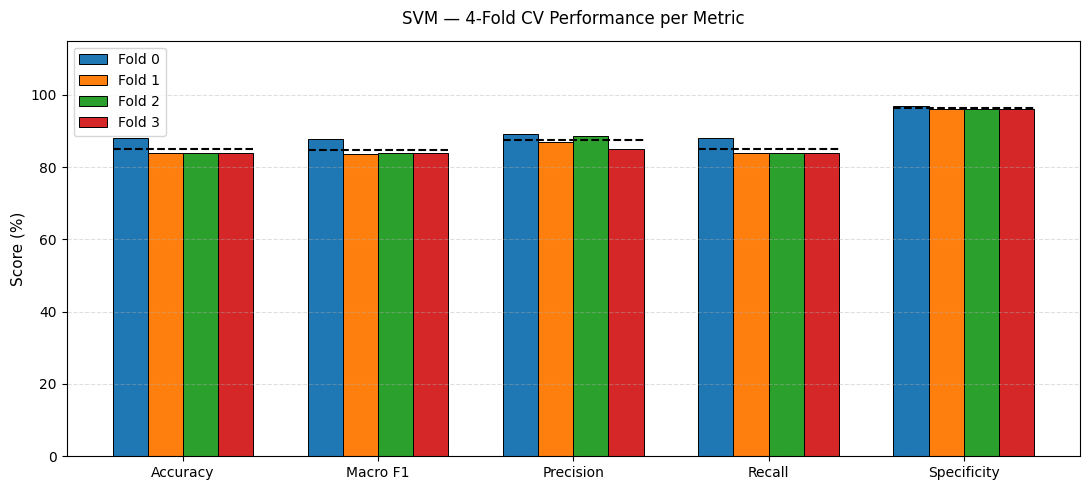

Saved: cv_fold_performance_thesis.png / .pdf

All figures saved to: C:\Users\manoj\Desktop\Thesis\svm_seg_results\thesis_figures


In [11]:
# ── Figure 1: Thesis-quality confusion matrix ──────────────────────
cm = met_te["cm"]

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm.astype(float) / cm.sum(axis=1, keepdims=True),
    display_labels=CLASS_LABELS,
)
disp.plot(ax=ax, cmap="Blues", colorbar=True, values_format=".2f")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i + 0.25,
            f"(n={cm[i, j]})",
            ha="center", va="center", fontsize=8,
            color="white" if cm[i, j] / cm[i].sum() > 0.5 else "black",
        )

ax.set_title("SVM — Normalised Confusion Matrix (Test Set)", fontsize=12, pad=12)
ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label", fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / "confusion_matrix_thesis.png", dpi=300, bbox_inches="tight")
plt.savefig(FIG_DIR / "confusion_matrix_thesis.pdf", bbox_inches="tight")
plt.show()
print("Saved: confusion_matrix_thesis.png / .pdf")

# ── Figure 2: Per-class ROC curves ──────────────────────────────────
y_te_bin = label_binarize(y_te, classes=CLASSES)
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

fig, ax = plt.subplots(figsize=(7, 6))
for i, c in enumerate(CLASSES):
    if len(np.unique(y_te_bin[:, i])) < 2:
        continue
    fpr, tpr, _ = roc_curve(y_te_bin[:, i], y_prob_te[:, i])
    auc_i = roc_auc_score(y_te_bin[:, i], y_prob_te[:, i])
    ax.plot(fpr, tpr, color=colors[i], lw=2,
            label=f"{CLASS_NAMES[c]} (AUC = {auc_i:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", lw=1, label="Random classifier")
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title("SVM — Per-Class ROC Curves (Test Set)", fontsize=12, pad=12)
ax.legend(loc="lower right", fontsize=10)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(FIG_DIR / "roc_curves_thesis.png", dpi=300, bbox_inches="tight")
plt.savefig(FIG_DIR / "roc_curves_thesis.pdf", bbox_inches="tight")
plt.show()
print("Saved: roc_curves_thesis.png / .pdf")

# ── Figure 3: Bootstrap CI bar chart ────────────────────────────────
names  = [r["display_name"] for r in boot_summary_rows]
means  = [r["mean"]         for r in boot_summary_rows]
ci_low = [r["ci95_low"]     for r in boot_summary_rows]
ci_hi  = [r["ci95_high"]    for r in boot_summary_rows]
err_lo = np.array(means) - np.array(ci_low)
err_hi = np.array(ci_hi) - np.array(means)
x_pos  = np.arange(len(names))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    x_pos, means,
    yerr=[err_lo, err_hi],
    capsize=5,
    color="steelblue", edgecolor="black", linewidth=0.8,
    error_kw={"elinewidth": 1.2, "ecolor": "black"},
)
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.015,
            f"{mean:.3f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x_pos)
ax.set_xticklabels(names, rotation=25, ha="right", fontsize=10)
ax.set_ylabel("Score", fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_title("SVM — Test Bootstrap Performance (mean ± 95% CI, B=1000)",
             fontsize=12, pad=12)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(FIG_DIR / "bootstrap_bar_thesis.png", dpi=300, bbox_inches="tight")
plt.savefig(FIG_DIR / "bootstrap_bar_thesis.pdf", bbox_inches="tight")
plt.show()
print("Saved: bootstrap_bar_thesis.png / .pdf")

# ── Figure 4: Per-class metrics bar chart ───────────────────────────
report = classification_report(
    y_te, y_pred_te,
    labels=CLASSES,
    target_names=CLASS_LABELS,
    output_dict=True,
    zero_division=0,
)
per_class_precision = [report[cls]["precision"] for cls in CLASS_LABELS]
per_class_recall    = [report[cls]["recall"]    for cls in CLASS_LABELS]
per_class_f1        = [report[cls]["f1-score"]  for cls in CLASS_LABELS]

x = np.arange(len(CLASS_LABELS))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width, per_class_precision, width, label="Precision",
       color="steelblue", edgecolor="black", linewidth=0.7)
ax.bar(x,          per_class_recall,   width, label="Recall (Sensitivity)",
       color="coral", edgecolor="black", linewidth=0.7)
ax.bar(x + width,  per_class_f1,       width, label="F1-score",
       color="mediumseagreen", edgecolor="black", linewidth=0.7)

for i, (p, r, f) in enumerate(zip(per_class_precision, per_class_recall, per_class_f1)):
    ax.text(i - width, p + 0.01, f"{p:.2f}", ha="center", fontsize=8)
    ax.text(i,         r + 0.01, f"{r:.2f}", ha="center", fontsize=8)
    ax.text(i + width, f + 0.01, f"{f:.2f}", ha="center", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(CLASS_LABELS, fontsize=11)
ax.set_xlabel("Diagnostic Class", fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_title("SVM — Per-Class Classification Metrics (Test Set)",
             fontsize=12, pad=12)
ax.legend(fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(FIG_DIR / "per_class_metrics_thesis.png", dpi=300, bbox_inches="tight")
plt.savefig(FIG_DIR / "per_class_metrics_thesis.pdf", bbox_inches="tight")
plt.show()
print("Saved: per_class_metrics_thesis.png / .pdf")

# ── Figure 5: CV fold performance bar chart ─────────────────────────
metric_cols = ["Accuracy", "Macro F1", "Precision", "Recall", "Specificity"]
fold_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

cv_display = pd.DataFrame([{
    "Accuracy":    round(row["acc"] * 100, 1),
    "Macro F1":    round(row["f1_macro"] * 100, 1),
    "Precision":   round(row["precision_macro"] * 100, 1),
    "Recall":      round(row["recall_macro"] * 100, 1),
    "Specificity": round(row["specificity_macro"] * 100, 1),
} for row in cv_df.to_dict("records")])

x_cv = np.arange(len(metric_cols))
n_folds = 4
bar_w   = 0.18

fig, ax = plt.subplots(figsize=(11, 5))
for fold_idx in range(n_folds):
    fold_vals = [cv_display.loc[fold_idx, col] for col in metric_cols]
    offset = (fold_idx - (n_folds - 1) / 2) * bar_w
    ax.bar(x_cv + offset, fold_vals, bar_w,
           label=f"Fold {fold_idx}",
           color=fold_colors[fold_idx], edgecolor="black", linewidth=0.7)

for j, col in enumerate(metric_cols):
    mean_val = cv_display[col].mean()
    ax.hlines(mean_val,
              j - n_folds / 2 * bar_w,
              j + n_folds / 2 * bar_w,
              colors="black", linewidths=1.5, linestyles="--")

ax.set_xticks(x_cv)
ax.set_xticklabels(metric_cols, fontsize=10)
ax.set_ylabel("Score (%)", fontsize=11)
ax.set_ylim(0, 115)
ax.set_title("SVM — 4-Fold CV Performance per Metric",
             fontsize=12, pad=12)
ax.legend(fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(FIG_DIR / "cv_fold_performance_thesis.png", dpi=300, bbox_inches="tight")
plt.savefig(FIG_DIR / "cv_fold_performance_thesis.pdf", bbox_inches="tight")
plt.show()
print("Saved: cv_fold_performance_thesis.png / .pdf")

print(f"\nAll figures saved to: {FIG_DIR}")

## 11. Export Summary

In [12]:
summary = {
    "experiment": "SVM_Seg",
    "features": FEATURE_COLS,
    "cv_results": {
        "per_fold": cv_rows,
        "mean": {col: float(np.mean(cv_df[col].values))
                 for col in ["acc", "f1_macro", "precision_macro", "recall_macro",
                             "balanced_acc", "specificity_macro", "auc_macro_ovr"]},
        "std": {col: float(np.std(cv_df[col].values, ddof=1))
                for col in ["acc", "f1_macro", "precision_macro", "recall_macro",
                            "balanced_acc", "specificity_macro", "auc_macro_ovr"]},
    },
    "test_results": {
        "acc":               float(met_te["acc"]),
        "f1_macro":          float(met_te["f1_macro"]),
        "precision_macro":   float(met_te["precision_macro"]),
        "recall_macro":      float(met_te["recall_macro"]),
        "balanced_acc":      float(met_te["balanced_acc"]),
        "specificity_macro": float(met_te["specificity_macro"]),
        "auc_macro_ovr":     float(met_te["auc_macro_ovr"]),
    },
    "bootstrap": {
        r["metric"]: {"mean": r["mean"], "std": r["std"],
                      "ci95_low": r["ci95_low"], "ci95_high": r["ci95_high"]}
        for r in boot_summary_rows
    },
}

with open(OUT_DIR / "summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(f"All results saved to: {OUT_DIR}")

All results saved to: C:\Users\manoj\Desktop\Thesis\svm_seg_results
